# Actividad 2: Web Scraping

**Objetivo:** Aplicar procesos de web scraping como una fuente de datos dentro de una solución de Big Data.
**Alumno:** Martín Eduardo Chacón Orduño  
**Matrícula:** 351840  
**Materia:** Big Data  
**Actividad:** 3.12 Actividad 2  
**Fecha:** 01/10/2026

## Ejercicio 1

IMDB impide las solicitudes automatizadas. Por lo que se utilizó Rotten Tomatoes como sitio similar.

Para cada pelicula se extraerán, el titulo y el Popcornmeter, que representa la puntuación de la audiencia. Posteriormente se construirá un DataFrame y una gráfica comparativa.

In [58]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt 

from bs4 import BeautifulSoup

print("Libraries impored correctly")

Libraries impored correctly


In [59]:
test_url = "https://www.rottentomatoes.com/m/top_gun_maverick"

headers = {
    "User-agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"
        "AppleWebKit/537.36 (KHTML, Like Gecko) "
        "Chrome/129.0 Safari/537.36"
    ),
    "Accept-Language": "en-US, en;q=0.9",
}

response = requests.get(test_url, headers=headers, timeout=20)

print(f"Status code: {response.status_code}")

Status code: 200


In [60]:
response.raise_for_status()

soup = BeautifulSoup(response.text, "lxml")

rating_element = soup.select_one('media-scorecard rt-text[slot="audience-score"]')
title_element = soup.select_one("h1#media-hero-label")

title = title_element.get_text(strip=True)
rating = int(rating_element.get_text(strip=True).replace("%", ""))

print(f"Title: {title}")
print(f"Rating: {rating}")


Title: Top Gun: Maverick
Rating: 99


In [61]:
initial_rotten_url = "https://rottentomatoes.com/m/"
movies_title = [
    "top_gun_maverick",
    "joker_2019",
    "forrest_gump",
    "star_wars_episode_iv_a_new_hope",
    "titanic",
]

movies_url = [initial_rotten_url + movie for movie in movies_title]
print(movies_url)


['https://rottentomatoes.com/m/top_gun_maverick', 'https://rottentomatoes.com/m/joker_2019', 'https://rottentomatoes.com/m/forrest_gump', 'https://rottentomatoes.com/m/star_wars_episode_iv_a_new_hope', 'https://rottentomatoes.com/m/titanic']


In [62]:
def scrape_movie(url):
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "lxml")

    title_element = soup.select_one("h1#media-hero-label")
    rating_element = soup.select_one('media-scorecard rt-text[slot="audience-score"]')

    if title_element is None:
        raise ValueError(f"Title not found: {url}")
    if rating_element is None:
        raise ValueError(F"Rating element not found: {url}")
    
    title = title_element.get_text(strip=True)
    rating = int(rating_element.get_text(strip=True).replace("%", ""))

    return {
        "Title": title,
        "Audience Rating": rating,
        "Source URL": url
    }

In [63]:
movies = []

for movie_url in movies_url:
    movie = scrape_movie(movie_url)
    movies.append(movie)

    print(f"{movie['Title']} - Rating: {movie['Audience Rating']}%")

    time.sleep(1)


Top Gun: Maverick - Rating: 99%
Joker - Rating: 89%
Forrest Gump - Rating: 95%
Star Wars: Episode IV - A New Hope - Rating: 96%
Titanic - Rating: 69%


### Organización de los resultados

Los datos extraídos se almacenan en un DataFrame para presnetarlos de maner estructurada y facilitar su análisis.

In [64]:
movies_df = pd.DataFrame(movies)
movies_df

,Title,Audience Rating,Source URL
0,Top Gun: Maverick,99,https://rottentomatoes.com/m/top_gun_maverick
1,Joker,89,https://rottentomatoes.com/m/joker_2019
2,Forrest Gump,95,https://rottentomatoes.com/m/forrest_gump
3,Star Wars: Episode IV - A New Hope,96,https://rottentomatoes.com/m/star_wars_episode...
4,Titanic,69,https://rottentomatoes.com/m/titanic


### Visualización de las puntuaciones

La siguiente gráfica de barras permite comparar las puntuaciones de audiencia obtenidas por las películas

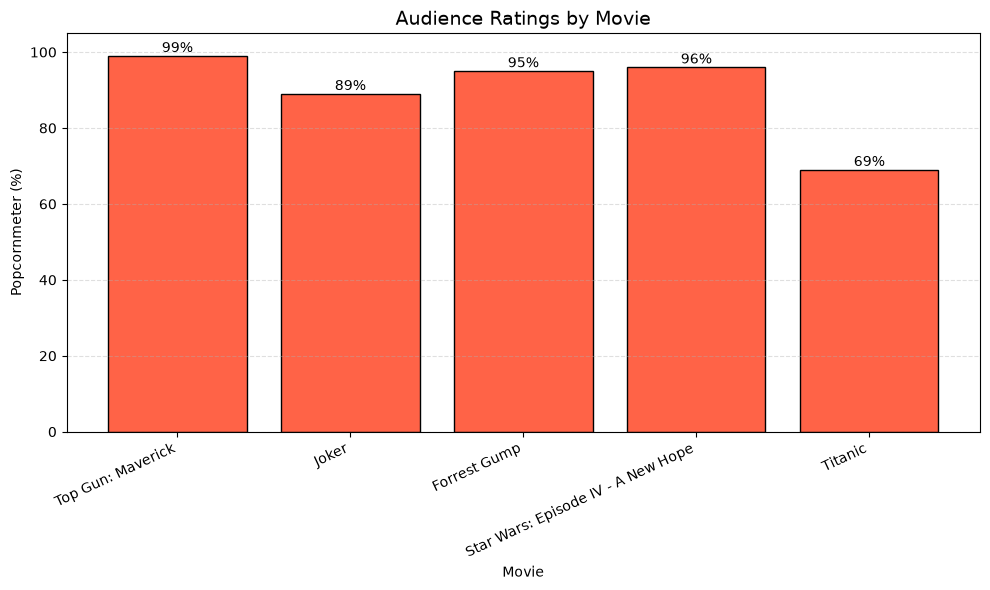

In [65]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    movies_df["Title"],
    movies_df["Audience Rating"],
    color="tomato",
    edgecolor="black"
)

plt.title("Audience Ratings by Movie", fontsize=14)
plt.xlabel("Movie")
plt.ylabel("Popcornmeter (%)")
plt.ylim(0, 105)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, rating in zip(bars, movies_df["Audience Rating"]):
    plt.text(bar.get_x() + bar.get_width() / 2, rating + 1, f"{rating}%", ha="center")

plt.tight_layout()
plt.savefig("movie_ratings.png", dpi=300, bbox_inches="tight")
plt.show()

## Ejercicio 2: Extracción de ofertas de trabajo

La actividad propone utilizar Indeed; sin embargo, sus condiciones actuales restringen
la extracción automatizada de datos. Por esta razón, se seleccionó Remote OK como
sitio alternativo.

Se extraerán el puesto, la empresa, la ubicación y el salario de ofertas relacionadas
con desarrollo de software.

In [46]:
jobs_url = "https://remoteok.com/remote-dev-jobs"

jobs_response = requests.get(jobs_url, headers=headers, timeout=20)

jobs_response.raise_for_status()
jobs_response

<Response [200]>

### Identificación de las ofertas en el HTML

El contenido HTML se analiza con Beautiful Soup. Las ofertas de trabajo de Remote OK
se encuentran dentro de filas de tabla identificadas con la clase `job`.

In [47]:
jobs_soup = BeautifulSoup(jobs_response.text, "lxml")

job_rows = jobs_soup.select("tr.job")

print(len(job_rows))

if job_rows:
    print(f"Available attributes: {list(job_rows[0].attrs.keys())}")

first_job = job_rows[0]

for element in first_job.find_all(
    ["h2", "h3", "span", "td"]
):
    element_text = element.get_text(
        " ",
        strip=True
    )

    if element_text:
        print(
            element.name,
            element.get("class"),
            "->",
            element_text[:200]
        )

9
Available attributes: ['class']


### Obtención de los datos dinámicos

La página inicial contiene filas vacías porque las ofertas se cargan dinámicamente
mediante JavaScript. Para obtener los registros de forma permitida y confiable, se
utiliza el feed JSON público de Remote OK.

In [48]:
jobs_api_url = "https://remoteok.com/api"

api_headers = {
    "User-Agent": "AcademicDataCollection/1.0",
    "Accept": "application/json"
}

jobs_api_response = requests.get(
    jobs_api_url,
    headers=api_headers,
    timeout=20
)

jobs_api_response.raise_for_status()

api_data = jobs_api_response.json()

job_records = [
    record
    for record in api_data
    if isinstance(record, dict)
    and record.get("position")
]

print("Job records received:", len(job_records))

if job_records:
    print(
        "Available fields:",
        list(job_records[0].keys())
    )

Job records received: 99
Available fields: ['slug', 'id', 'epoch', 'date', 'company', 'company_logo', 'position', 'tags', 'description', 'location', 'salary_min', 'salary_max', 'apply_url', 'original', 'logo', 'url']


In [49]:
software_keywords = [
    "developer",
    "programmer",
    "software",
    "backend",
    "frontend",
    "full stack",
    "fullstack"
]


def format_salary(record):
    salary_min = float(
        record.get("salary_min") or 0
    )
    salary_max = float(
        record.get("salary_max") or 0
    )

    if salary_min and salary_max:
        return (
            f"${salary_min:,.0f} - "
            f"${salary_max:,.0f} USD"
        )

    if salary_min:
        return f"From ${salary_min:,.0f} USD"

    if salary_max:
        return f"Up to ${salary_max:,.0f} USD"

    return "Not specified"


software_jobs = []

for record in job_records:
    position = str(
        record.get("position", "")
    )

    tags = record.get("tags") or []
    tags_text = " ".join(tags)

    searchable_text = (
        f"{position} {tags_text}".lower()
    )

    if any(
        keyword in searchable_text
        for keyword in software_keywords
    ):
        software_jobs.append(
            {
                "Title": position,
                "Company": record.get(
                    "company",
                    "Not specified"
                ),
                "Location": record.get(
                    "location"
                ) or "Remote",
                "Salary": format_salary(record)
            }
        )

    if len(software_jobs) == 15:
        break


jobs_df = pd.DataFrame(software_jobs)

jobs_df

,Title,Company,Location,Salary
0,Software Engineer,Prenosis,Remote,Not specified
1,Frontend Engineer,Bjak,Singapore,Not specified
2,Software Developer Security Analytics,RedMimicry,Remote,Not specified
3,Senior .NET Software Engineer,OkWhen,Remote,Not specified
4,Frontend Engineer,Bjak,Ireland,Not specified
5,Backend Software Engineer,Airspace Link,Remote,Not specified
6,Software Deployment Engineer,KPI Solutions,Cincinnati,Not specified
7,Senior Shopify Developer,Sanctuary Computer,Remote,"$80,000 - $250,000 USD"
8,Software Engineer,Mirantis,Remote,Not specified
9,Senior Backend Engineer Build AI Agents,Salesforge,Remote,Not specified


In [50]:
print("Number of jobs:", len(jobs_df))
print("\nMissing values by column:")
print(jobs_df.isna().sum())

jobs_df.to_csv(
    "remote_software_jobs.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nFile created successfully: "
    "remote_software_jobs.csv"
)

Number of jobs: 15

Missing values by column:
Title       0
Company     0
Location    0
Salary      0
dtype: int64

File created successfully: remote_software_jobs.csv


### Conclusión del ejercicio 2

La página de Remote OK carga las ofertas dinámicamente, por lo que el HTML recibido
inicialmente no contenía todos los datos visibles. Se utilizó su feed JSON público
para obtener los registros de manera estructurada.

Las ofertas relacionadas con desarrollo de software se filtraron mediante palabras
clave y se organizaron en un DataFrame con el puesto, la empresa, la ubicación y el
salario. Cuando alguna oferta no proporcionó un dato, este se identificó como no
especificado. Finalmente, los resultados se guardaron en formato CSV.

## Ejercicio 3: Apple Store en Texas

Se seleccionó el estado de Texas para recopilar el nombre y la dirección de sus
tiendas Apple. Primero se obtendrá el listado de establecimientos y posteriormente
se consultará la página individual de cada tienda. Los resultados se guardarán en
el archivo `storeapple.csv`.

In [51]:
apple_store_url = "https://www.apple.com/retail/storelist/"

apple_response = requests.get(apple_store_url, headers=headers, timeout=20)

print(apple_response)

apple_response.raise_for_status()

apple_soup = BeautifulSoup(apple_response.text, "lxml")

texas_heading = next(
    (
        heading for heading in apple_soup.find_all("h2")
        if heading.get_text(strip=True) == "Texas"
    ),
    None
)

print(f"texas section found {texas_heading is not None}")

<Response [200]>
texas section found True


In [52]:
from urllib.parse import urljoin

store_links = []
seen_urls = set()

for element in texas_heading.find_all_next():
    if element.name == "h2":
        break

    if element.name == "a":
        relative_url = element.get("href", "")
        store_name = element.get_text(
            " ",
            strip=True
        )

        if (
            relative_url.startswith("/retail/")
            and store_name
        ):
            store_url = urljoin(
                apple_store_url,
                relative_url
            )

            if store_url not in seen_urls:
                store_links.append(
                    {
                        "Store Name": store_name,
                        "Store URL": store_url
                    }
                )
                seen_urls.add(store_url)

print("Store links found:", len(store_links))

Store links found: 17


In [53]:
apple_stores = []

for store in store_links:
    store_response = requests.get(
        store["Store URL"],
        headers=headers,
        timeout=20
    )
    store_response.raise_for_status()

    store_soup = BeautifulSoup(
        store_response.text,
        "lxml"
    )

    address_element = store_soup.find("address")

    if address_element:
        address_lines = [
            " ".join(text.split())
            for text in address_element.stripped_strings
            if text.strip() != "Open in maps"
            and not text.strip().startswith("(")
        ]

        address = ", ".join(address_lines)
    else:
        address = "Address not found"

    apple_stores.append(
        {
            "Store Name": store["Store Name"],
            "Address": address
        }
    )

    time.sleep(1)

In [54]:
apple_stores_df = pd.DataFrame(
    apple_stores
)

apple_stores_df.to_csv(
    "storeapple.csv",
    index=False,
    encoding="utf-8-sig"
)

apple_stores_df

,Store Name,Address
0,Domain NORTHSIDE,"3121 Palm Way, Austin, ,, TX, 78758"
1,Barton Creek,"2901 S. Capital of Texas Hwy, Austin, ,, TX, 7..."
2,NorthPark Center,"8687 North Central Expressway, Dallas, ,, TX, ..."
3,Knox Street,"3101 Knox Street, Dallas, ,, TX, 75205"
4,Galleria Dallas,"13350 Dallas Parkway, Dallas, ,, TX, 75240"
5,Cielo Vista Mall,"8401 Gateway Boulevard West, El Paso, ,, TX, 7..."
6,University Park Village,"1540 S. University Drive, Fort Worth, ,, TX, 7..."
7,Baybrook,"500 Baybrook Mall, Friendswood, ,, TX, 77546"
8,Memorial City,"303 Memorial City, Houston, ,, TX, 77024"
9,Houston Galleria,"5085 Westheimer Road, Houston, ,, TX, 77056"


## Ejercicio 4: Artículos científicos de arXiv

Se extraen los primeros diez artículos recientes de la categoría Databases de arXiv.
Para cada artículo se obtiene su identificador, título, autores, temas y enlace.

In [55]:
articles_url = "https://arxiv.org/list/cs.DB/recent"

article_headers = {
    "User-Agent": "AcademicDataCollection/1.0"
}

articles_response = requests.get(
    articles_url,
    headers=article_headers,
    timeout=20
)

articles_response.raise_for_status()

articles_soup = BeautifulSoup(
    articles_response.text,
    "lxml"
)

In [56]:
article_ids = articles_soup.select(
    "dl#articles > dt"
)

article_details = articles_soup.select(
    "dl#articles > dd"
)

articles = []

for identifier, details in zip(
    article_ids[:10],
    article_details[:10]
):
    abstract_link = identifier.select_one(
        'a[title="Abstract"]'
    )

    title_element = details.select_one(
        "div.list-title"
    )

    authors_element = details.select_one(
        "div.list-authors"
    )

    subjects_element = details.select_one(
        "div.list-subjects"
    )

    article_id = abstract_link.get_text(
        " ",
        strip=True
    )

    article_url = urljoin(
        articles_url,
        abstract_link["href"]
    )

    title = title_element.get_text(
        " ",
        strip=True
    ).replace("Title:", "", 1).strip()

    authors = authors_element.get_text(
        " ",
        strip=True
    ).replace("Authors:", "", 1).strip()

    subjects = subjects_element.get_text(
        " ",
        strip=True
    ).replace("Subjects:", "", 1).strip()

    articles.append(
        {
            "Article ID": article_id,
            "Title": title,
            "Authors": authors,
            "Subjects": subjects,
            "URL": article_url
        }
    )

In [57]:
articles_df = pd.DataFrame(articles)

articles_df.to_csv(
    "scientific_articles.csv",
    index=False,
    encoding="utf-8-sig"
)

articles_df

,Article ID,Title,Authors,Subjects,URL
0,arXiv:2609.39778,Scalable Approximate Algorithm for Dynamic Den...,"Jingbang Chen , Chenhao Ma , Yingli Zhou",Databases (cs.DB),https://arxiv.org/abs/2609.39778
1,arXiv:2609.39412,Recommendation Systems for Exploratory Data Tasks,Anna Fariha,Databases (cs.DB),https://arxiv.org/abs/2609.39412
2,arXiv:2609.39209,O-Funnel: Lossless Structural Capture and Requ...,Osama Mustafa,Databases (cs.DB) ; Information Retrieval (cs.IR),https://arxiv.org/abs/2609.39209
3,arXiv:2609.39058,A 3GPP-Compliant Benchmark Dataset for RIS-Aid...,"Pujitha Mamillapalli , Pankaj Singh Rathour , ...",Databases (cs.DB) ; Artificial Intelligence (c...,https://arxiv.org/abs/2609.39058
4,arXiv:2609.38439,Automated Prefetching for Object Spatial Progr...,"Baichuan Li , Jayanaka Dantanarayana , Savini ...",Databases (cs.DB) ; Programming Languages (cs.PL),https://arxiv.org/abs/2609.38439
5,arXiv:2609.40018,Separating Notions of Graph Width: the Adaptiv...,"Matthias Lanzinger , Timo Camillo Merkl , Dan ...",Combinatorics (math.CO) ; Databases (cs.DB),https://arxiv.org/abs/2609.40018
6,arXiv:2609.39257,From Benchmarks to Production: Transferring Ti...,"Nicolas Vautier , Paul Caron , Nardi Xhepi , F...",Machine Learning (cs.LG) ; Artificial Intellig...,https://arxiv.org/abs/2609.39257
7,arXiv:2609.38193,EHR2Trace: Auditable EHR Data Infrastructure f...,"Xinye Yang , Yuli Wang , Cheng Ting Lin , Harr...",Machine Learning (cs.LG) ; Artificial Intellig...,https://arxiv.org/abs/2609.38193
8,arXiv:2609.38053,VADER: Filtered Vector Search with Declarative...,"Manos Chatzakis , Duo Lu , Helena Caminal , Ya...",Databases (cs.DB),https://arxiv.org/abs/2609.38053
9,arXiv:2609.36795,Epistemic Typing as a PostgreSQL Table Access ...,"Venkata Maguluri , Swapna Kommuri , Kritica Si...",Databases (cs.DB) ; Cryptography and Security ...,https://arxiv.org/abs/2609.36795


## Conclusiones

La actividad permitió aplicar diferentes técnicas de recopilación de datos desde
fuentes web. Se utilizó Beautiful Soup para procesar páginas HTML estáticas y un
feed JSON para obtener información cargada dinámicamente.

También se comprobó la importancia de revisar las políticas de acceso de cada sitio,
respetar los tiempos entre solicitudes y utilizar fuentes alternativas cuando un
portal restringe la extracción automatizada.

Los datos obtenidos se organizaron en estructuras de pandas y se exportaron a archivos
CSV para facilitar su almacenamiento y análisis posterior.

## Fuentes consultadas

- [Rotten Tomatoes](https://www.rottentomatoes.com/)
- [Remote OK](https://remoteok.com/)
- [Apple Retail Store List](https://www.apple.com/retail/storelist/)
- [arXiv Databases](https://arxiv.org/list/cs.DB/recent)